In [ ]:
import pandas as pd
from urllib.request import urlretrieve
import numpy as np

In [ ]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'
urlretrieve(data, "data.csv")

df = pd.read_csv("data.csv")
df.head()

In [ ]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
print(df.columns)

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='object')


In [20]:
string = list(df.dtypes[df.dtypes == 'object'].index)
for col in string:
    df[col] = df[col].str.lower().str.replace(" ", '_')
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [41]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

Make
['bmw' 'audi' 'fiat' 'mercedes-benz' 'chrysler']
48

Model
['1_series_m' '1_series' '100' '124_spider' '190-class']
914

Year
[2011 2012 2013 1992 1993]
28

Engine Fuel Type
['premium_unleaded_(required)' 'regular_unleaded'
 'premium_unleaded_(recommended)' 'flex-fuel_(unleaded/e85)' 'diesel']
10

Engine HP
[335. 300. 230. 320. 172.]
356

Engine Cylinders
[ 6.  4.  5.  8. 12.]
9

Transmission Type
['manual' 'automatic' 'automated_manual' 'direct_drive' 'unknown']
5

Driven_Wheels
['rear_wheel_drive' 'front_wheel_drive' 'all_wheel_drive'
 'four_wheel_drive']
4

Number of Doors
[ 2.  4.  3. nan]
3

Market Category
['factory_tuner,luxury,high-performance' 'luxury,performance'
 'luxury,high-performance' 'luxury' 'performance']
71

Vehicle Size
['compact' 'midsize' 'large']
3

Vehicle Style
['coupe' 'convertible' 'sedan' 'wagon' '4dr_hatchback']
16

highway MPG
[26 28 27 25 24]
59

city mpg
[19 20 18 17 16]
69

Popularity
[3916 3105  819  617 1013]
48

MSRP
[46135 40650 36350 29450 345

<Axes: xlabel='MSRP', ylabel='Count'>

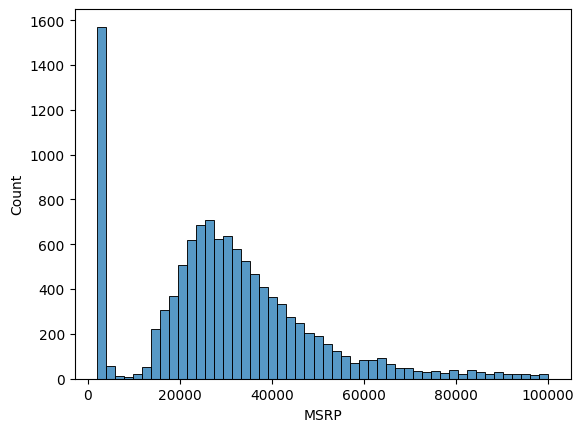

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.histplot(df["MSRP"][df.MSRP < 100000], bins=50)

<Axes: xlabel='MSRP', ylabel='Count'>

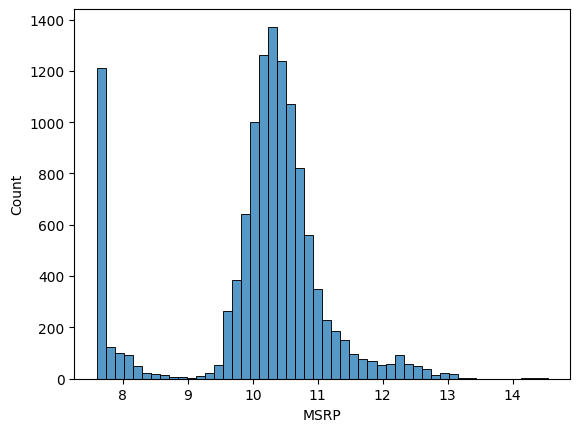

In [48]:
price_logs = np.log1p(df.MSRP)
sns.histplot(price_logs, bins = 50)

In [49]:
df.isnull().sum()

Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

In [54]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test
print(n, n_train, n_val, n_test)

11914 7150 2382 2382


In [4]:
idx = np.arange(n)
np.random.seed(2)
np.random.shuffle(idx)
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_val+n_train]]
df_test = df.iloc[idx[n_val+n_train:]]

NameError: name 'n' is not defined